# XGBoost Classification (From Scratch)
## UCI Credit Card Default Dataset

สร้าง XGBoost จาก scratch (ไม่ใช้ library xgboost)

In [1]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split
from imblearn.over_sampling import SMOTE
import helper

In [2]:
df = helper.prepare_data()

## XGBoost From Scratch Implementation

### หลักการ XGBoost:
1. ใช้ Gradient Boosting ที่ build tree เรียงต่อกัน โดยแต่ละ tree จะ fit gradient (อนุพันธ์อันดับ 1) และ hessian (อนุพันธ์อันดับ 2) ของ loss function
2. สำหรับ binary classification ใช้ log loss:
   - gradient: g_i = p_i - y_i (โดย p_i = sigmoid(raw_score))
   - hessian: h_i = p_i * (1 - p_i)
3. Gain สำหรับ split: 0.5 * [G_L²/(H_L+λ) + G_R²/(H_R+λ) - (G_L+G_R)²/(H_L+H_R+λ)] - γ
4. Optimal leaf weight: w* = -G / (H + λ)
5. แต่ละ tree ทำนาย score ที่นำมาบวกกับ score เดิม (additive training)

In [3]:
class XGBoostTreeNode:
  """Node สำหรับ regression tree ใน XGBoost"""
  def __init__(self, feature_index=None, threshold=None, left=None, right=None, leaf_weight=None):
    self.feature_index = feature_index
    self.threshold = threshold
    self.left = left
    self.right = right
    # leaf weight (ค่า output ของ leaf node)
    self.leaf_weight = leaf_weight

  def is_leaf(self):
    return self.leaf_weight is not None


class XGBoostTree:
  """Single regression tree สำหรับ XGBoost
  ใช้ gradient และ hessian ในการ build tree
  """
  def __init__(self, max_depth=6, min_child_weight=1, reg_lambda=1.0, gamma=0.0):
    self.max_depth = max_depth
    self.min_child_weight = min_child_weight
    self.reg_lambda = reg_lambda  # L2 regularization
    self.gamma = gamma  # minimum gain to split
    self.root = None

  def _calculate_leaf_weight(self, gradients, hessians):
    """คำนวณ optimal leaf weight: w* = -G / (H + λ)"""
    return -np.sum(gradients) / (np.sum(hessians) + self.reg_lambda)

  def _calculate_gain(self, gradients, hessians):
    """คำนวณ gain score สำหรับ node: 0.5 * G² / (H + λ)"""
    return 0.5 * (np.sum(gradients) ** 2) / (np.sum(hessians) + self.reg_lambda)

  def _calculate_split_gain(self, left_gradients, left_hessians, right_gradients, right_hessians):
    """คำนวณ gain จากการ split:
    Gain = 0.5 * [G_L²/(H_L+λ) + G_R²/(H_R+λ) - (G_L+G_R)²/(H_L+H_R+λ)] - γ
    """
    left_gain = self._calculate_gain(left_gradients, left_hessians)
    right_gain = self._calculate_gain(right_gradients, right_hessians)
    all_gradients = np.concatenate([left_gradients, right_gradients])
    all_hessians = np.concatenate([left_hessians, right_hessians])
    total_gain = self._calculate_gain(all_gradients, all_hessians)
    return left_gain + right_gain - total_gain - self.gamma

  def _find_best_split(self, X, gradients, hessians):
    """หา feature และ threshold ที่ให้ gain สูงสุด"""
    best_gain = 0
    best_feature = None
    best_threshold = None
    n_samples, n_features = X.shape

    for feature_idx in range(n_features):
      # หา unique values เป็น threshold candidates
      thresholds = np.unique(X[:, feature_idx])

      for threshold in thresholds:
        left_mask = X[:, feature_idx] >= threshold
        right_mask = ~left_mask

        # skip ถ้า split แล้วฝั่งใดฝั่งหนึ่งว่าง
        if np.sum(left_mask) == 0 or np.sum(right_mask) == 0:
          continue

        # ตรวจสอบ min_child_weight
        left_hessian_sum = np.sum(hessians[left_mask])
        right_hessian_sum = np.sum(hessians[right_mask])
        if left_hessian_sum < self.min_child_weight or right_hessian_sum < self.min_child_weight:
          continue

        gain = self._calculate_split_gain(
          gradients[left_mask], hessians[left_mask],
          gradients[right_mask], hessians[right_mask]
        )

        if gain > best_gain:
          best_gain = gain
          best_feature = feature_idx
          best_threshold = threshold

    return best_feature, best_threshold, best_gain

  def _build_tree(self, X, gradients, hessians, current_depth=0):
    """สร้าง tree แบบ recursive"""
    n_samples = X.shape[0]

    # ถ้าถึง max_depth หรือ samples น้อยเกินไป → สร้าง leaf
    if current_depth >= self.max_depth or n_samples <= 1:
      leaf_weight = self._calculate_leaf_weight(gradients, hessians)
      return XGBoostTreeNode(leaf_weight=leaf_weight)

    # หา best split
    best_feature, best_threshold, best_gain = self._find_best_split(X, gradients, hessians)

    # ถ้า gain ไม่ดีพอ → สร้าง leaf
    if best_feature is None or best_gain <= 0:
      leaf_weight = self._calculate_leaf_weight(gradients, hessians)
      return XGBoostTreeNode(leaf_weight=leaf_weight)

    # split data
    left_mask = X[:, best_feature] >= best_threshold
    right_mask = ~left_mask

    # build subtrees
    left_child = self._build_tree(X[left_mask], gradients[left_mask], hessians[left_mask], current_depth + 1)
    right_child = self._build_tree(X[right_mask], gradients[right_mask], hessians[right_mask], current_depth + 1)

    return XGBoostTreeNode(
      feature_index=best_feature,
      threshold=best_threshold,
      left=left_child,
      right=right_child
    )

  def fit(self, X, gradients, hessians):
    """Train tree ด้วย gradients และ hessians"""
    self.root = self._build_tree(X, gradients, hessians)

  def _predict_sample(self, x, node):
    """ทำนาย 1 sample"""
    if node.is_leaf():
      return node.leaf_weight

    if x[node.feature_index] >= node.threshold:
      return self._predict_sample(x, node.left)
    else:
      return self._predict_sample(x, node.right)

  def predict(self, X):
    """ทำนายทั้ง dataset"""
    return np.array([self._predict_sample(x, self.root) for x in X])


class XGBoostClassifierFromScratch:
  """XGBoost Binary Classifier สร้างจาก scratch
  ใช้ log loss (binary cross-entropy) เป็น objective function
  """
  def __init__(self, n_estimators=100, max_depth=6, learning_rate=0.1,
               min_child_weight=1, reg_lambda=1.0, gamma=0.0, subsample=1.0,
               colsample_bytree=1.0):
    self.n_estimators = n_estimators
    self.max_depth = max_depth
    self.learning_rate = learning_rate  # eta (shrinkage)
    self.min_child_weight = min_child_weight
    self.reg_lambda = reg_lambda
    self.gamma = gamma
    self.subsample = subsample
    self.colsample_bytree = colsample_bytree
    self.trees = []
    self.base_score = 0.5  # initial prediction (probability)

  @staticmethod
  def _sigmoid(x):
    """Sigmoid function with clipping to avoid overflow"""
    x = np.clip(x, -500, 500)
    return 1.0 / (1.0 + np.exp(-x))

  def _compute_gradients_hessians(self, y_true, y_pred_proba):
    """คำนวณ gradient และ hessian สำหรับ log loss
    gradient: g_i = p_i - y_i
    hessian: h_i = p_i * (1 - p_i)
    """
    gradients = y_pred_proba - y_true
    hessians = y_pred_proba * (1 - y_pred_proba)
    # clamp hessians to avoid numerical issues
    hessians = np.maximum(hessians, 1e-16)
    return gradients, hessians

  def fit(self, X, y):
    """Train XGBoost model"""
    self.trees = []
    n_samples, n_features = X.shape

    # initial raw score (log-odds of base_score)
    self.initial_prediction = np.log(self.base_score / (1 - self.base_score))
    raw_predictions = np.full(n_samples, self.initial_prediction)

    for i in range(self.n_estimators):
      # คำนวณ probabilities จาก raw scores
      y_pred_proba = self._sigmoid(raw_predictions)

      # คำนวณ gradients และ hessians
      gradients, hessians = self._compute_gradients_hessians(y, y_pred_proba)

      # Subsample (row subsampling)
      if self.subsample < 1.0:
        sample_size = int(n_samples * self.subsample)
        indices = np.random.choice(n_samples, size=sample_size, replace=False)
      else:
        indices = np.arange(n_samples)

      # Column subsampling
      if self.colsample_bytree < 1.0:
        n_cols = max(1, int(n_features * self.colsample_bytree))
        col_indices = np.random.choice(n_features, size=n_cols, replace=False)
      else:
        col_indices = np.arange(n_features)

      X_subset = X[np.ix_(indices, col_indices)]
      g_subset = gradients[indices]
      h_subset = hessians[indices]

      # สร้าง tree
      tree = XGBoostTree(
        max_depth=self.max_depth,
        min_child_weight=self.min_child_weight,
        reg_lambda=self.reg_lambda,
        gamma=self.gamma
      )
      tree.fit(X_subset, g_subset, h_subset)

      # เก็บ tree พร้อม column indices ที่ใช้
      self.trees.append((tree, col_indices))

      # update raw predictions ด้วย learning rate
      update = tree.predict(X[:, col_indices])
      raw_predictions += self.learning_rate * update

      # print progress ทุก 50 trees
      if (i + 1) % 10 == 0:
        current_proba = self._sigmoid(raw_predictions)
        current_preds = (current_proba >= 0.5).astype(int)
        acc = np.mean(current_preds == y)
        print(f'  Tree {i+1}/{self.n_estimators} - Training Accuracy: {acc:.4f}')

  def predict_proba(self, X):
    """ทำนาย probability (class 1)"""
    raw_predictions = np.full(X.shape[0], self.initial_prediction)

    for tree, col_indices in self.trees:
      raw_predictions += self.learning_rate * tree.predict(X[:, col_indices])

    return self._sigmoid(raw_predictions)

  def predict(self, X):
    """ทำนาย class (0 หรือ 1)"""
    proba = self.predict_proba(X)
    return (proba >= 0.5).astype(int)

## 1. Prepare Data (PAY Features Only)
ใช้เฉพาะ PAY_0 - PAY_6 เหมือน models อื่นใน project

In [4]:
X = df[['PAY_0', 'PAY_2', 'PAY_3', 'PAY_4', 'PAY_5', 'PAY_6']].values
y = df['default.payment.next.month'].values
X, y = SMOTE(random_state=42).fit_resample(X, y)
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)
scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

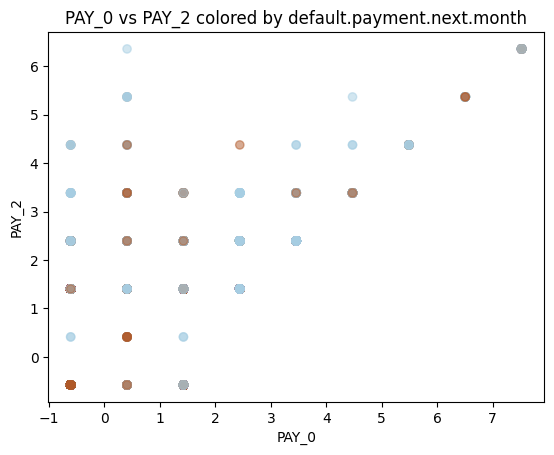

In [5]:
# scatter plot only first two features
plt.scatter(X_train[:, 0], X_train[:, 1], c=y_train, cmap='Paired_r', alpha=0.5)
plt.xlabel('PAY_0')
plt.ylabel('PAY_2')
plt.title('PAY_0 vs PAY_2 colored by default.payment.next.month')
plt.show()

## 2. Train XGBoost From Scratch (PAY Features)

Training XGBoost From Scratch (PAY Features)...
  Tree 10/100 - Training Accuracy: 0.7272
  Tree 20/100 - Training Accuracy: 0.7273
  Tree 30/100 - Training Accuracy: 0.7274
  Tree 40/100 - Training Accuracy: 0.7276
  Tree 50/100 - Training Accuracy: 0.7277
  Tree 60/100 - Training Accuracy: 0.7278
  Tree 70/100 - Training Accuracy: 0.7279
  Tree 80/100 - Training Accuracy: 0.7280
  Tree 90/100 - Training Accuracy: 0.7281
  Tree 100/100 - Training Accuracy: 0.7281
Training complete!
Accuracy: 0.7241761284962615
Confusion Matrix:


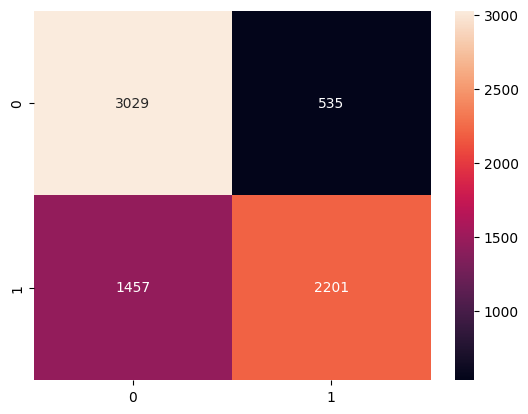

Classification Report:
              precision    recall  f1-score   support

           0       0.68      0.85      0.75      3564
           1       0.80      0.60      0.69      3658

    accuracy                           0.72      7222
   macro avg       0.74      0.73      0.72      7222
weighted avg       0.74      0.72      0.72      7222



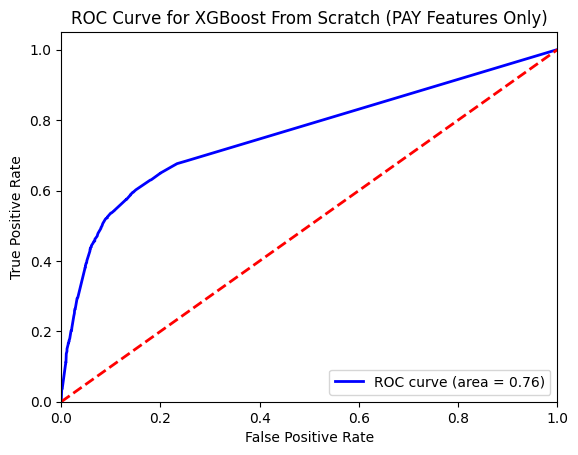

In [6]:
xgb_scratch_pay = XGBoostClassifierFromScratch(
    n_estimators=100,
    max_depth=4,
    learning_rate=0.1,
    min_child_weight=1,
    reg_lambda=1.0,
    gamma=0.0,
    subsample=0.8,
    colsample_bytree=0.8
)
print('Training XGBoost From Scratch (PAY Features)...')
xgb_scratch_pay.fit(X_train, y_train)
print('Training complete!')

y_pred = xgb_scratch_pay.predict(X_test)
y_pred_proba = xgb_scratch_pay.predict_proba(X_test)
helper.evaluate_model(y_test, y_pred)
helper.plot_roc_curve(y_test, y_pred_proba, title='XGBoost From Scratch (PAY Features Only)')

## 3. XGBoost From Scratch with All Features
ใช้ทุก features ใน dataset (ยกเว้น target)

In [7]:
df2 = helper.prepare_data()
X_all = df2.drop('default.payment.next.month', axis=1).values
y_all = df2['default.payment.next.month'].values
X_all, y_all = SMOTE(random_state=42).fit_resample(X_all, y_all)
X_train_all, X_test_all, y_train_all, y_test_all = train_test_split(
    X_all, y_all, test_size=0.2, random_state=42
)
scaler_all = StandardScaler()
X_train_all = scaler_all.fit_transform(X_train_all)
X_test_all = scaler_all.transform(X_test_all)

Training XGBoost From Scratch (All Features)...
  Tree 10/100 - Training Accuracy: 0.8526
  Tree 20/100 - Training Accuracy: 0.8669
  Tree 30/100 - Training Accuracy: 0.8701
  Tree 40/100 - Training Accuracy: 0.8743
  Tree 50/100 - Training Accuracy: 0.8766
  Tree 60/100 - Training Accuracy: 0.8790
  Tree 70/100 - Training Accuracy: 0.8799
  Tree 80/100 - Training Accuracy: 0.8811
  Tree 90/100 - Training Accuracy: 0.8816
  Tree 100/100 - Training Accuracy: 0.8819
Training complete!
Accuracy: 0.870949875380781
Confusion Matrix:


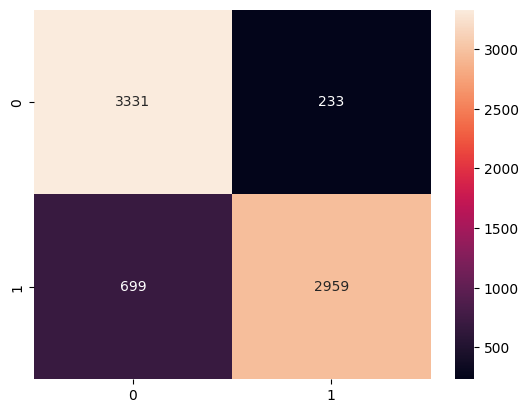

Classification Report:
              precision    recall  f1-score   support

           0       0.83      0.93      0.88      3564
           1       0.93      0.81      0.86      3658

    accuracy                           0.87      7222
   macro avg       0.88      0.87      0.87      7222
weighted avg       0.88      0.87      0.87      7222



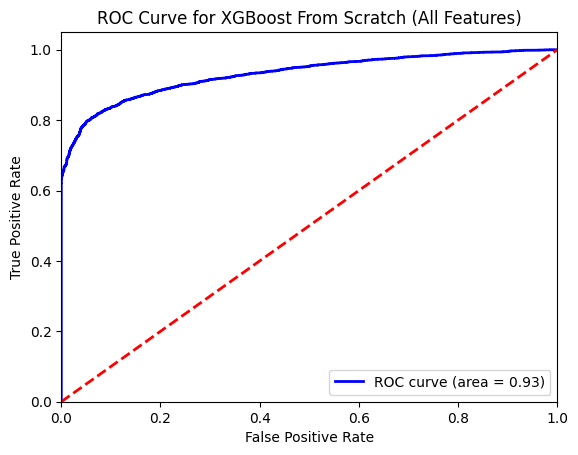

In [ ]:
xgb_scratch_all = XGBoostClassifierFromScratch(
    n_estimators=100,
    max_depth=4,
    learning_rate=0.1,
    min_child_weight=1,
    reg_lambda=1.0,
    gamma=0.0,
    subsample=0.8,
    colsample_bytree=0.8
)
print('Training XGBoost From Scratch (All Features)...')
xgb_scratch_all.fit(X_train_all, y_train_all)
print('Training complete!')

y_pred_all = xgb_scratch_all.predict(X_test_all)
y_pred_proba_all = xgb_scratch_all.predict_proba(X_test_all)
helper.evaluate_model(y_test_all, y_pred_all)
helper.plot_roc_curve(y_test_all, y_pred_proba_all, title='XGBoost From Scratch (All Features)')